In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/keras-pretrained-models/inception_resnet_v2_weights_tf_dim_ordering_tf_kernels_notop.h5
/kaggle/input/keras-pretrained-models/inception_v3_weights_tf_dim_ordering_tf_kernels.h5
/kaggle/input/keras-pretrained-models/resnet50_weights_tf_dim_ordering_tf_kernels.h5
/kaggle/input/keras-pretrained-models/resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5
/kaggle/input/keras-pretrained-models/xception_weights_tf_dim_ordering_tf_kernels_notop.h5
/kaggle/input/keras-pretrained-models/inception_v3_weights_tf_dim_ordering_tf_kernels_notop.h5
/kaggle/input/keras-pretrained-models/imagenet_class_index.json
/kaggle/input/keras-pretrained-models/vgg16_weights_tf_dim_ordering_tf_kernels_notop.h5
/kaggle/input/keras-pretrained-models/Kuszma.JPG
/kaggle/input/keras-pretrained-models/xception_weights_tf_dim_ordering_tf_kernels.h5
/kaggle/input/keras-pretrained-models/inception_resnet_v2_weights_tf_dim_ordering_tf_kernels.h5
/kaggle/input/efficientnet-weights/efficientnetb3_notop.h5
/kaggl

## Import Libraries

In [2]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.image import imread
%matplotlib inline

# tensorflow libraries
import tensorflow as tf
from tensorflow import keras
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential, Model
from keras.layers import Flatten, InputLayer, Dense, Conv2D, MaxPooling2D, Dropout
from keras import optimizers
from keras.applications.vgg16 import VGG16
from keras.applications.inception_v3 import InceptionV3


## Reading Data

In [3]:
sample_submission= pd.read_csv("/kaggle/input/cassava-leaf-disease-classification/sample_submission.csv")
train_df= pd.read_csv("/kaggle/input/cassava-leaf-disease-classification/train.csv")
class_labels= pd.read_json("/kaggle/input/cassava-leaf-disease-classification/label_num_to_disease_map.json", orient="index")

# class_labels = class_labels.values.flatten().tolist()

In [4]:
train_df.head()

,image_id,label
0,1000015157.jpg,0
1,1000201771.jpg,3
2,100042118.jpg,1
3,1000723321.jpg,1
4,1000812911.jpg,3


#### *Let's define image directories*

In [5]:
base_dir= "/kaggle/input/cassava-leaf-disease-classification"
train_img_dir=  "/kaggle/input/cassava-leaf-disease-classification/train_images/"

print("training images:\n", os.listdir(train_img_dir)[:5])
print("\n Number of training images :", len(os.listdir(train_img_dir)))

training images:
 ['1235188286.jpg', '1215607589.jpg', '478554372.jpg', '2763304605.jpg', '2826122413.jpg']

 Number of training images : 21397


#### *Classes to which these training images belong to*

In [6]:
print(class_labels)

                                     0
0       Cassava Bacterial Blight (CBB)
1  Cassava Brown Streak Disease (CBSD)
2           Cassava Green Mottle (CGM)
3         Cassava Mosaic Disease (CMD)
4                              Healthy



#### *Let's find out the total number of Diseased and Healthy images*

In [7]:
print("Number of healthy leaves images :" , train_df[train_df["label"] == 4].shape[0])
print("Number of diseased leaves images :", train_df[train_df["label"] != 4].shape[0])

Number of healthy leaves images : 2577
Number of diseased leaves images : 18820


#### *Now let's take a look at a few pictures of what the diseased and healthy cells look like.*

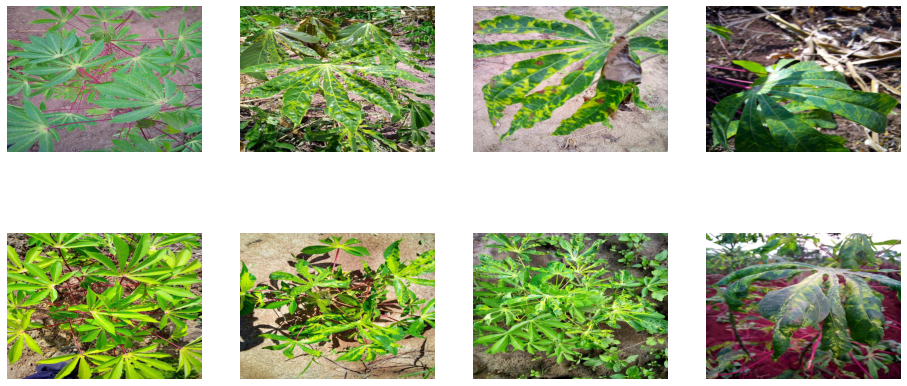

In [8]:
nrows = 4
ncols = 4

pic_index = 0 

fig = plt.gcf()
fig.set_size_inches(ncols*4, nrows*4)

pic_index+=8

images = [os.path.join(train_img_dir, image) 
                for image in os.listdir(train_img_dir)[ pic_index-8:pic_index] ]


for i, image_path in enumerate(images):
  
  sp = plt.subplot(nrows, ncols, i + 1)
  sp.axis('Off')

  img = mpimg.imread(image_path)
  plt.imshow(img)

plt.show()

In [9]:
image= imread("/kaggle/input/cassava-leaf-disease-classification/train_images/1235188286.jpg")
image.shape

(600, 800, 3)

### Data Augmentation

In [10]:
train_df['label'] = train_df['label'].astype('string')

# generating traning set
print("training set :")
train_datagen= ImageDataGenerator(rescale=1/255, zoom_range=0.3, rotation_range=50,
                                   width_shift_range=0.2, height_shift_range=0.2, shear_range=0.2, 
                                   horizontal_flip=True, fill_mode='nearest', validation_split = 0.2)

train_data= train_datagen.flow_from_dataframe(train_df,
                                              train_img_dir,
                                              target_size = (300, 300),
                                              class_mode = "categorical",
                                              batch_size = 20,
                                              x_col = "image_id", y_col = "label",
                                              shuffle = True, subset = "training")


# generating validation set
print("\nvalidation set :")
val_datagen= ImageDataGenerator(rescale=1/255, validation_split = 0.2)

val_data= val_datagen.flow_from_dataframe(train_df,
                                          train_img_dir,
                                          target_size = (300, 300),
                                          class_mode = "categorical",
                                          batch_size = 20,
                                          x_col = "image_id", y_col = "label",
                                          shuffle = False, subset = "validation")

training set :
Found 17118 validated image filenames belonging to 5 classes.

validation set :
Found 4279 validated image filenames belonging to 5 classes.


# Inception ResnetV2 Model

In [11]:
from keras.applications import InceptionResNetV2

# with include_top= False we are not using fully connected layer of the Inception_resnet model, instead we
# will create our own Fully Connected and Output Layer according to our training data
inception_resnet= InceptionResNetV2(input_shape= (300, 300,3), include_top= False, 
                       weights="../input/keras-pretrained-models/inception_resnet_v2_weights_tf_dim_ordering_tf_kernels_notop.h5")


# Since we are creating our own fully connected layer we need output of the last inception model layer and flatten them
last_output= inception_resnet.layers[-1].output

# Flattening the last output
last_output= Flatten()(last_output)

# pretrained model
inception_model= Model(inception_resnet.input, last_output)

In [12]:
inception_model.summary()

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 300, 300, 3) 0                                            
__________________________________________________________________________________________________
conv2d (Conv2D)                 (None, 149, 149, 32) 864         input_1[0][0]                    
__________________________________________________________________________________________________
batch_normalization (BatchNorma (None, 149, 149, 32) 96          conv2d[0][0]                     
__________________________________________________________________________________________________
activation (Activation)         (None, 149, 149, 32) 0           batch_normalization[0][0]        
______________________________________________________________________________________________

### Creating Top Layers

In [13]:
from keras import optimizers

x= Dense(units= 512, activation= "relu")(last_output)
x= Dropout(0.2)(x)

x= Dense(units= 128, activation= "relu")(x)
x= Dropout(0.2)(x)

x= Dense(units= 5, activation= "softmax")(x)

# final model
model= Model(inception_model.input, x)

model.compile(loss= "categorical_crossentropy", optimizer=optimizers.RMSprop(lr=1e-4), metrics=["accuracy"])
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 300, 300, 3) 0                                            
__________________________________________________________________________________________________
conv2d (Conv2D)                 (None, 149, 149, 32) 864         input_1[0][0]                    
__________________________________________________________________________________________________
batch_normalization (BatchNorma (None, 149, 149, 32) 96          conv2d[0][0]                     
__________________________________________________________________________________________________
activation (Activation)         (None, 149, 149, 32) 0           batch_normalization[0][0]        
____________________________________________________________________________________________

### Model Fitting

In [14]:
# Since the layers of Inception_resnet model are already trained, we don't want them to be trained again. 
# So we will freeze them
for layer in inception_model.layers:
    layer.trainable= False

# fitting only Top layers     
history= model.fit(train_data, epochs=20,
                   steps_per_epoch= train_data.samples//train_data.batch_size,
                   validation_data= val_data,
                   validation_steps= val_data.samples//val_data.batch_size,
                   batch_size= 20, verbose= 2)  

Epoch 1/20
855/855 - 724s - loss: 1.0099 - accuracy: 0.6985 - val_loss: 1.9476 - val_accuracy: 0.7793
Epoch 2/20
855/855 - 607s - loss: 0.7934 - accuracy: 0.7846 - val_loss: 0.6594 - val_accuracy: 0.8221
Epoch 3/20
855/855 - 600s - loss: 0.6748 - accuracy: 0.8141 - val_loss: 5.8340 - val_accuracy: 0.8108
Epoch 4/20
855/855 - 603s - loss: 0.5911 - accuracy: 0.8221 - val_loss: 0.8637 - val_accuracy: 0.8228
Epoch 5/20
855/855 - 604s - loss: 0.6182 - accuracy: 0.8295 - val_loss: 0.4564 - val_accuracy: 0.8458
Epoch 6/20
855/855 - 606s - loss: 0.5316 - accuracy: 0.8402 - val_loss: 1.7212 - val_accuracy: 0.7643
Epoch 7/20
855/855 - 610s - loss: 0.4974 - accuracy: 0.8454 - val_loss: 0.5303 - val_accuracy: 0.8249
Epoch 8/20
855/855 - 607s - loss: 0.4781 - accuracy: 0.8485 - val_loss: 0.9192 - val_accuracy: 0.8411
Epoch 9/20
855/855 - 609s - loss: 0.4847 - accuracy: 0.8548 - val_loss: 0.8367 - val_accuracy: 0.8481
Epoch 10/20
855/855 - 612s - loss: 0.5112 - accuracy: 0.8485 - val_loss: 0.5385 - 

### Model Evaluation

In [15]:
history.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

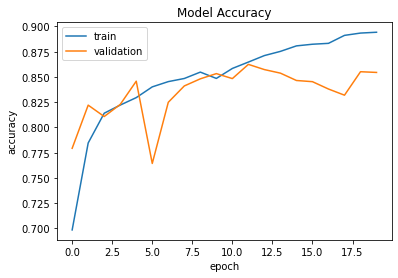

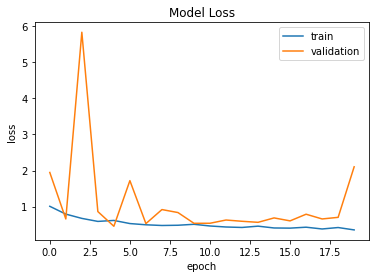

In [16]:
epochs= range(len(history.history["accuracy"]))
# accuracy plot
plt.plot(epochs, history.history["accuracy"])
plt.plot(epochs, history.history["val_accuracy"])
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("Model Accuracy")
plt.legend(["train", "validation"])
plt.show()

# loss plot
plt.plot(epochs, history.history["loss"])
plt.plot(epochs, history.history["val_loss"])
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Model Loss")
plt.legend(["train", "validation"])
plt.show()

# Model Submission

In [17]:
preds = []
sample_submission = pd.read_csv('../input/cassava-leaf-disease-classification/sample_submission.csv')

for image in sample_submission.image_id:
    img = tf.keras.preprocessing.image.load_img('../input/cassava-leaf-disease-classification/test_images/' + image)
    img = tf.keras.preprocessing.image.img_to_array(img)
    img = tf.keras.preprocessing.image.smart_resize(img, (300, 300))
    img = tf.reshape(img, (-1, 300, 300, 3))
    prediction = model.predict(img/255)
    preds.append(np.argmax(prediction))

submission = pd.DataFrame({'image_id': sample_submission.image_id, 'label': preds})
submission.to_csv('submission.csv', index=False)        

In [18]:
submission

,image_id,label
0,2216849948.jpg,2
